# Regular TransE

In [1]:
import numpy as np
import pandas as pd
import torch
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import pickle
import torch.nn as nn
import random
from collections import defaultdict
import re
import json
import time
import requests
from datetime import datetime
import ast

Import CPE

In [2]:
df_cpe = pd.read_csv("../preprocess/csv_file/2021aug/cpe_ignore_version.csv", usecols=['part','vendor',
                'product', 'target_sw','target_hw','name','size']).sort_values(
                'size', ascending=False)

Import CVE

In [3]:
df_cve = pd.read_csv("../preprocess/csv_file/2021aug/cve/cve-2002.csv")
df_cve = df_cve.astype('object').fillna('*')
df_list = [df_cve]
for i in range(2003, 2022):
    filename = f'../preprocess/csv_file/2021aug/cve/cve-{i}.csv'
    df_temp = pd.read_csv(filename)
    df_temp = df_temp.astype('object').fillna('*')
    df_list.append(df_temp)
df_cve = pd.concat(df_list, ignore_index=True)


Import CWE

In [4]:
df_cwe = pd.read_csv("../preprocess/csv_file/2021aug/cwe.csv")
df_cwe.fillna('*', inplace=True)

df_cwe_cate = pd.read_csv("../preprocess/csv_file/2021aug/cwe_category.csv")
df_cwe_view = pd.read_csv("../preprocess/csv_file/2021aug/cwe_view.csv")
df_cwe_cate.fillna('*', inplace=True)
df_cwe_view.fillna('*', inplace=True)

,ID,Name,Type,Status,Has_Member
0,CWE-1000,"""Research Concepts""",Graph,Draft,CWE-284;CWE-435;CWE-664;CWE-682;CWE-691;CWE-69...
1,CWE-1003,"""Weaknesses for Simplified Mapping of Publishe...",Graph,Incomplete,CWE-20;CWE-74;CWE-116;CWE-119;CWE-200;CWE-269;...
2,CWE-1008,"""Architectural Concepts""",Graph,Incomplete,CWE-1009;CWE-1010;CWE-1011;CWE-1012;CWE-1013;C...
3,CWE-1026,"""Weaknesses in OWASP Top Ten (2017)""",Graph,Incomplete,CWE-1027;CWE-1028;CWE-1029;CWE-1030;CWE-1031;C...
4,CWE-1040,"""Quality Weaknesses with Indirect Security Imp...",Implicit,Incomplete,*
5,CWE-1081,"""Entries with Maintenance Notes""",Implicit,Draft,*
6,CWE-1128,"""CISQ Quality Measures (2016)""",Graph,Incomplete,CWE-1129;CWE-1130;CWE-1131;CWE-1132
7,CWE-1133,"""Weaknesses Addressed by the SEI CERT Oracle C...",Graph,Stable,CWE-1134;CWE-1135;CWE-1136;CWE-1137;CWE-1138;C...
8,CWE-1154,"""Weaknesses Addressed by the SEI CERT C Coding...",Graph,Stable,CWE-1155;CWE-1156;CWE-1157;CWE-1158;CWE-1159;C...
9,CWE-1178,"""Weaknesses Addressed by the SEI CERT Perl Cod...",Graph,Stable,CWE-1179;CWE-1180;CWE-1181;CWE-1182;CWE-1183;C...


In [5]:
print("The size of df_cpe, df_cve, df_cwe are:", df_cpe.shape[0], df_cve.shape[0], df_cwe.shape[0])

The size of df_cpe, df_cve, df_cwe are: 68338 167542 918


In [6]:
#reproducible performance
num = 50
random.seed(num)
np.random.seed(num)
torch.manual_seed(num)
torch.cuda.manual_seed(num)
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [7]:
class TransE(nn.Module):
    def __init__(self, num_entities, num_relations, embedding_dim):
        super(TransE, self).__init__()
        self.num_entities = num_entities
        self.num_relations = num_relations
        self.embedding_dim = embedding_dim

        self.entity_embeddings = nn.Embedding(num_entities, embedding_dim)
        self.relation_embeddings = nn.Embedding(num_relations, embedding_dim)
        

        nn.init.xavier_uniform_(self.entity_embeddings.weight.data)
        nn.init.xavier_uniform_(self.relation_embeddings.weight.data)

    def forward(self, pos_triples, neg_triples):
        pos_score = self.score_triples(pos_triples)

        # reshaping b/c >1 neg triple per pos triple 
        # (batch_size, num_neg, 3) -> (batch_size * num_neg, 3)
        batch_size, num_neg, _ = neg_triples.shape
        neg_triples = neg_triples.view(-1, 3)

        neg_score = self.score_triples(neg_triples)
        return pos_score, neg_score

    def predict(self, triples):
        return self.score_triples(triples)

    # transe scoring - higher score = better fit.
    # this can be changed for distmult (h*r*t) or complex
    def score_triples(self, triples):
        h = self.entity_embeddings(triples[:, 0])
        r = self.relation_embeddings(triples[:, 1])
        t = self.entity_embeddings(triples[:, 2])

        # ampligraph defaults to l1 norm
        score = -torch.norm(h + r - t, p=1, dim=1)
        return score

In [8]:
class ComplEx(nn.Module):
    def __init__(self, num_entities, num_relations, embedding_dim):
        super(ComplEx, self).__init__()

        self.num_entities = num_entities
        self.num_relations = num_relations
        self.embedding_dim = embedding_dim

        # Real and imaginary parts
        self.entity_embeddings_real = nn.Embedding(
            num_entities, embedding_dim
        )
        self.entity_embeddings_imag = nn.Embedding(
            num_entities, embedding_dim
        )

        self.relation_embeddings_real = nn.Embedding(
            num_relations, embedding_dim
        )
        self.relation_embeddings_imag = nn.Embedding(
            num_relations, embedding_dim
        )

        # AmpliGraph supports Xavier/Glorot initialization.
        nn.init.xavier_uniform_(self.entity_embeddings_real.weight)
        nn.init.xavier_uniform_(self.entity_embeddings_imag.weight)

        nn.init.xavier_uniform_(self.relation_embeddings_real.weight)
        nn.init.xavier_uniform_(self.relation_embeddings_imag.weight)

    def forward(self, pos_triples, neg_triples):

        pos_score = self.score_triples(pos_triples)

        # (batch_size, num_neg, 3)
        # -> (batch_size * num_neg, 3)
        batch_size, num_neg, _ = neg_triples.shape
        neg_triples = neg_triples.view(-1, 3)

        neg_score = self.score_triples(neg_triples)

        return pos_score, neg_score

    def predict(self, triples):
        return self.score_triples(triples)

    def score_triples(self, triples):

        h_real = self.entity_embeddings_real(triples[:, 0])
        h_imag = self.entity_embeddings_imag(triples[:, 0])

        r_real = self.relation_embeddings_real(triples[:, 1])
        r_imag = self.relation_embeddings_imag(triples[:, 1])

        t_real = self.entity_embeddings_real(triples[:, 2])
        t_imag = self.entity_embeddings_imag(triples[:, 2])

        # Re(<r, h, conjugate(t)>)
        score = torch.sum(
            r_real * h_real * t_real
            + r_real * h_imag * t_imag
            + r_imag * h_real * t_imag
            - r_imag * h_imag * t_real,
            dim=1
        )

        return score

In [9]:
class DistMult(nn.Module):
    def __init__(self, num_entities, num_relations, embedding_dim):
        super(DistMult, self).__init__()
        self.num_entities = num_entities
        self.num_relations = num_relations
        self.embedding_dim = embedding_dim

        self.entity_embeddings = nn.Embedding(num_entities, embedding_dim)
        self.relation_embeddings = nn.Embedding(num_relations, embedding_dim)
 

        nn.init.xavier_uniform_(self.entity_embeddings.weight.data)
        nn.init.xavier_uniform_(self.relation_embeddings.weight.data)

    def forward(self, pos_triples, neg_triples):
        pos_score = self.score_triples(pos_triples)

        # reshaping b/c >1 neg triple per pos triple 
        # (batch_size, num_neg, 3) -> (batch_size * num_neg, 3)
        batch_size, num_neg, _ = neg_triples.shape
        neg_triples = neg_triples.view(-1, 3)

        neg_score = self.score_triples(neg_triples)
        return pos_score, neg_score

    def predict(self, triples):
        return self.score_triples(triples)

    # DistMult scoring:
    # f(h,r,t) = sum(h * r * t)
    # Higher score = better fit
    def score_triples(self, triples):
        h = self.entity_embeddings(triples[:, 0])
        r = self.relation_embeddings(triples[:, 1])
        t = self.entity_embeddings(triples[:, 2])

        score = torch.sum(h * r * t, dim=1)

        return score

In [10]:
class RotatE(nn.Module):
    def __init__(self, num_entities, num_relations, embedding_dim, gamma=12.0):
        super(RotatE, self).__init__()

        self.num_entities = num_entities
        self.num_relations = num_relations
        self.embedding_dim = embedding_dim
        self.gamma = gamma

        # Entity embeddings: complex-valued vectors
        self.entity_embeddings_real = nn.Embedding(
            num_entities, embedding_dim
        )
        self.entity_embeddings_imag = nn.Embedding(
            num_entities, embedding_dim
        )

        # Relations are represented by phase angles
        self.relation_embeddings = nn.Embedding(
            num_relations, embedding_dim
        )

        # Xavier initialization for entities
        nn.init.xavier_uniform_(self.entity_embeddings_real.weight)
        nn.init.xavier_uniform_(self.entity_embeddings_imag.weight)

        # Initialize relation phases
        nn.init.uniform_(
            self.relation_embeddings.weight,
            -torch.pi,
            torch.pi
        )

    def forward(self, pos_triples, neg_triples):

        pos_score = self.score_triples(pos_triples)

        # (batch_size, num_neg, 3)
        # -> (batch_size * num_neg, 3)
        batch_size, num_neg, _ = neg_triples.shape
        neg_triples = neg_triples.view(-1, 3)

        neg_score = self.score_triples(neg_triples)

        return pos_score, neg_score

    def predict(self, triples):
        return self.score_triples(triples)

    def score_triples(self, triples):

        h_real = self.entity_embeddings_real(triples[:, 0])
        h_imag = self.entity_embeddings_imag(triples[:, 0])

        # Relation phase
        theta = self.relation_embeddings(triples[:, 1])

        r_real = torch.cos(theta)
        r_imag = torch.sin(theta)

        t_real = self.entity_embeddings_real(triples[:, 2])
        t_imag = self.entity_embeddings_imag(triples[:, 2])

        rotated_real = (
            h_real * r_real
            - h_imag * r_imag
        )

        rotated_imag = (
            h_real * r_imag
            + h_imag * r_real
        )

        # Distance between rotated head and tail
        diff_real = rotated_real - t_real
        diff_imag = rotated_imag - t_imag

        distance = torch.sqrt(
            diff_real ** 2 + diff_imag ** 2 + 1e-12
        )

        distance = torch.sum(distance, dim=1)

        # Higher score = better triple
        score = self.gamma - distance

        return score

In [11]:
def get_nearest_neighbors(model, query_entity_id, candidate_entity_ids, n=5):
    with torch.no_grad():
        entity_embs = model.entity_embeddings.weight 
        query_emb = entity_embs[query_entity_id]  

        #convert to tensor
        if not isinstance(candidate_entity_ids, torch.Tensor):
            candidate_entity_ids = torch.tensor(candidate_entity_ids, device=entity_embs.device)

        candidate_embs = entity_embs[candidate_entity_ids] 

        # L2 distances
        distances = torch.norm(candidate_embs - query_emb, p=2, dim=1)
        topk_vals, topk_indices = torch.topk(distances, k=n, largest=False)
        neighbors = [int(candidate_entity_ids[i]) for i in topk_indices]
        neighbors = [id2entity[ent] for ent in neighbors]
        return neighbors


Load Model for Evaluation

In [12]:
mtype = ""
with open(f"../threat_kg/id_conversions{mtype}/entity2id.pkl", "rb") as f:
    entity2id = pickle.load(f)

with open(f"../threat_kg/id_conversions{mtype}/id2entity.pkl", "rb") as f:
    id2entity = pickle.load(f)

with open(f"../threat_kg/id_conversions{mtype}/relation2id.pkl", "rb") as f:
    relation2id = pickle.load(f)

with open(f"../threat_kg/id_conversions{mtype}/id2relation.pkl", "rb") as f:
    id2relation = pickle.load(f)

triples_id = np.load(f"../threat_kg/id_conversions{mtype}/triples_id.npy")

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = 'cpu'
model = TransE(
    num_entities=len(entity2id),
    num_relations=len(relation2id),
    embedding_dim=100
)

# Load the saved weights
model.load_state_dict(torch.load(f"../threat_kg/models_trained_scc/transe_model_nll{mtype}.pt", map_location=device))
model.to(device)

# remove this if you just want to continue training
model.eval()  # set to evaluation mode


TransE(
  (entity_embeddings): Embedding(204428, 100)
  (relation_embeddings): Embedding(18, 100)
)

In [14]:
cwe_list = df_cwe['ID'].values.tolist()

In [15]:
#used for evaluation
def mr_score(ranks):
    return np.mean(ranks)


def mrr_score(ranks):
    return np.mean([1.0 / rank for rank in ranks])


def hits_at_n(ranks, n):
    return np.mean([rank <= n for rank in ranks])

In [16]:
df_cwe_1003 = pd.read_csv("../FixV2W/files/cwe-1003.csv", usecols=['CWE-ID', 'Weakness Abstraction'], index_col=False)
df_cwe_1003.fillna('*', inplace=True)
cwe_rels = pd.read_csv("../FixV2W/files/cwe_relations.csv")

cwe_sublist = []  # does not contain discouraged cwe from cwe-1003 list
cwe_1003 = []
cwe_disc = ["CWE-119", "CWE-20", "CWE-200", "CWE-269", "CWE-287",
            "CWE-311", "CWE-330", "CWE-345", "CWE-400", "CWE-610",
            "CWE-662", "CWE-665", "CWE-668", "CWE-682", "CWE-697",
            "CWE-74", "CWE-755", "CWE-834"]

for i, r in df_cwe_1003.iterrows():
    cweid = 'CWE-' + str(r['CWE-ID'])
    cwe_abs = r['Weakness Abstraction']
    cwe_1003.append(cweid)

    if cweid not in cwe_disc:
        cwe_sublist.append((cweid, cwe_abs))


In [17]:
cwe_dict = {}
for i, row in cwe_rels.iterrows():
    child = row['Child']
    parent = row['Parent']
    rel = row['Relationship']

    if rel == 'ChildOf':
        if child in cwe_dict:
            cwe_dict[child].append(parent)
        else:
            cwe_dict[child] = []
            cwe_dict[child].append(parent)

In [18]:
# this is similar to the query_topn() function we use in ampligraph
def query_topn(model, head_id, relation_id, candidate_tail_ids, top_n=10):
    model.eval()
    with torch.no_grad():
        # create copies of head and relation entities for all tail entities to query
        device='cpu'
        h = torch.tensor([head_id], device=device).long().repeat(len(candidate_tail_ids))
        r = torch.tensor([relation_id], device=device).long().repeat(len(candidate_tail_ids))
        t = torch.tensor(candidate_tail_ids, device=device).long()

        triples = torch.stack([h, r, t], dim=1)  # Shape: (num_candidates, 3)
        scores = model.predict(triples)         # Shape: (num_candidates,)

        sorted_scores, indices = torch.sort(scores, descending=True)  # larger scores are better
        sorted_tail_ids = [candidate_tail_ids[i] for i in indices.cpu().numpy()]
        sorted_scores = sorted_scores.cpu().numpy()

        # Return top N (or fewer if not enough candidates)
        return sorted_tail_ids[:top_n], sorted_scores[:top_n]

In [19]:
def get_sib_fam(cwe):
    family = []
    if cwe in cwe_dict:
        parents = cwe_dict[cwe]
        for p in parents:
            family.extend(get_cwe_children(p))
    return list(set(family))

In [20]:
# This is the first method I implemented to find family of the CWE. Usually, this yields a 
# large list of CWE that are related to each other, since we are returning the whole branch
# that CWE is in. Rather, we can also just return direct parents and children (below cell)

def get_cwe_parents(cwe):
    # given a cwe, find all related cwe that are in the same branch.
    family = []

    if cwe in cwe_dict:
        # exists as key - has parents.
        value = cwe_dict[cwe]
        for item in value:
            family.append(item)
            res = get_cwe_parents(item)  # recursively reach branch head and all 'grandparents'
            if res:
                family.extend(res)
    return family


def get_cwe_children(cwe):
    family = []
    if any(cwe in val for val in cwe_dict.values()):
        keys = [key for key, value in cwe_dict.items() if cwe in value]
        family.extend(keys)
        for item in keys:
            res = get_cwe_children(item)  
            if res:
                family.extend(res)
    return family


def get_cwe_family(cwe):
    return set(get_cwe_parents(cwe) + get_cwe_children(cwe))

In [21]:
def strtoList(string):
    ret = []
    arr = string.split("'")
    for i in arr:
        if len(i)>3:
            ret.append(i)
    return ret

In [22]:
# For the fine-grain analysis, we need only immediate family - direct children and parents
def get_direct_family(cwe):
    family = []

    if cwe in cwe_dict:
        # exists as key - has parents.
        value = cwe_dict[cwe]
        for item in value:
            family.append(item)
    if any(cwe in val for val in cwe_dict.values()):
        keys = [key for key, value in cwe_dict.items() if cwe in value]
        #print(keys)
        family.extend(keys)
    return family

In [23]:
# using df_cwe_cate or df_cwe_view for querying for CWEs in that list (that can be used to map CVEs i.e. in CWE-1003 list)
def get_cwe_subtree(cweid):
    cwe_members = []
    
    if cweid in df_cwe_cate['ID'].tolist():    
        item = df_cwe_cate.loc[df_cwe_cate['ID'] == cweid]
        cwe_str = item['Has_Member']
        cwe_members.extend(cwe_str.str.split(';'))
        
    elif cweid in df_cwe_view['ID'].tolist():  
        item = df_cwe_view.loc[df_cwe_view['ID'] == cweid]
        cwe_str = item['Has_Member']
        cwe_members.extend(cwe_str.str.split(';'))
    
    cwe_ret = []
    if cwe_members:
        for item in cwe_members[0]:
            if item in cwe_1003 and item not in cwe_ret:
                cwe_ret.append(item)

            #optionally comment out this for loop to avoid overcrowding the candidate list
            family = get_cwe_family(item)
            for x in family:
                if x in cwe_1003 and x not in cwe_ret:
                    cwe_ret.append(x)
    return cwe_ret

In [24]:
def extract_cwes_from_string(s):
    import re
    if not isinstance(s, str):
        return []
    # Find all CWE patterns like 'CWE-920'
    cwes = re.findall(r'CWE-\d+', s)
    return cwes

In [25]:
df_d = pd.read_csv('../FixV2W/files/new_filtered_query_d.csv')
df_p = pd.read_csv('../FixV2W/files/new_filtered_query_p.csv')

In [26]:
top25 = pd.read_csv('../FixV2W/files/cwe_top25.csv')['ID'].values.tolist()
top25_ids = [entity2id[cwe] for cwe in top25 if cwe in entity2id]

### Prohibited set

In [27]:
df_cwe = pd.read_csv("../preprocess/csv_file/2021aug/cwe.csv")
df_cwe.fillna('*', inplace=True)

df_cwe_cate = pd.read_csv("../preprocess/csv_file/2021aug/cwe_category.csv")
df_cwe_view = pd.read_csv("../preprocess/csv_file/2021aug/cwe_view.csv")
df_cwe_cate.fillna('*', inplace=True)
df_cwe_view.fillna('*', inplace=True)

new_cve_df = pd.read_csv('../FixV2W/files/cve2cwe_2024.csv')
df_cve2cwe = pd.read_csv('../FixV2W/files/df_cve2cwe.csv')
cwe_prohibited = df_cwe_cate["ID"].tolist() + df_cwe_view["ID"].tolist()

The code below runs the queries. We can experiment with the ```cwe_to_query``` variable to test different candidate sets.

In [28]:
results = {}
rel_id = relation2id['MatchingCWE']
total = 0
for i, pair in tqdm(df_p.iterrows(), total=len(df_p)):
    cwe_q = pair['CWE']
    cve_q = pair['CVE']
    cwe_to_query = get_cwe_subtree(cwe_q)
    if cwe_q == 'CWE-17':
        continue
        
    if len(cwe_to_query) == 0:
        #use nearest neighbors if no subtree members are found
        # cwe_1003_id = [entity2id[cwe] for cwe in cwe_1003 if cwe != cwe_q]
        # cwe_to_query = get_nearest_neighbors(model, entity2id[cwe_q], cwe_1003_id, n=10)

        #use cwe-1003 list if not subtree members are found
        cwe_to_query = [cwe for cwe in cwe_1003 if cwe != cwe_q]
    
    candidate_tail_ids = [entity2id[cwe] for cwe in cwe_to_query if cwe != cwe_q]
    # candidate_tail_ids = cwe_1003
    for cve in strtoList(cve_q):
        head_id = entity2id[cve]
        try:
            res = query_topn(model, head_id, rel_id, candidate_tail_ids)
            results[cve] = [res, cwe_q]          
        except:
            pass
        total +=1
end = time.time()
print('Total queries made: ', total)

  0%|          | 0/11 [00:00<?, ?it/s]

Total queries made:  337


In [29]:
data = []

for cve, (predictions, old_cwe) in results.items():
    rank_labels = [id2entity[pred] for pred in predictions[0]]
    scores = predictions[1]

    data.append({
        'CVE': cve,
        'Rank': rank_labels,
        'Score': scores,
        'Old CWE': old_cwe
    })

df_res = pd.DataFrame(data)
df_res.to_csv('cwe_proh_query.csv', index=False)

In [30]:
results_df_proh = pd.read_csv('cwe_proh_query.csv', names=["CVE", "Result", "Score", 'Old CWE'], skiprows=1)

In [31]:
cwe_cve_p = []

for i, pair in df_p.iterrows():
    cwe_q = pair['CWE']
    cve_q = pair['CVE']

    for cve in strtoList(cve_q):
        new_cve = new_cve_df.loc[new_cve_df["subject:START_ID"] == cve]
        new_cwe = new_cve['object:END_ID'].values
        
        old_cve = df_cve2cwe[df_cve2cwe["CVE"]==cve]
        old_cwe = old_cve['CWE'].values
        
        #print(new_cwe, old_cwe)
        for item in new_cwe:
            if item not in old_cwe: # added this to avoid evaluating for already existing CWE mappings prior to validation
                cwe_cve_p.append((cwe_q, cve, item))
        
df_compare_p = pd.DataFrame(cwe_cve_p, columns=['OldCWE', 'CVE', 'CWE-NVD']) #,'CWE-KG'])
df_compare_p['CWE-KG'] = None

In [32]:
for item in cwe_cve_p:
    cve = item[1]
    row_d = df_compare_p.loc[df_compare_p['CVE']==cve]
    
    row = results_df_proh.loc[results_df_proh['CVE']==cve]
    if not row.empty:
        cwe_ranked = row["Result"].apply(ast.literal_eval).values[0]
        df_compare_p.loc[df_compare_p['CVE']==cve,'CWE-KG'] = str(cwe_ranked)

In [33]:
not_found = 0

exact_match = []
fine_grain = []
coarse_grain = []
other_cve = []

for index, row in df_compare_p.iterrows():
    cve = row["CVE"]
    
    oldCWE = row["OldCWE"]
    newCWE = row["CWE-NVD"]
    try:
        kg_list = ast.literal_eval(row["CWE-KG"])
    except ValueError:
        kg_list = []
    match = False
        
    
    if newCWE in kg_list:
        match = True
        rank = kg_list.index(newCWE) + 1
        exact_match.append((cve, newCWE, rank))
    
    else:
        fam = get_direct_family(newCWE)
        fam_all = get_cwe_family(newCWE)
        for result in kg_list:
            if result in fam:
                
                match = True
                rank = kg_list.index(result) + 1
                fine_grain.append((cve, result, rank))
                break

        if not match:
            for result in kg_list:
                if result in fam_all:
                    match = True
                    rank = kg_list.index(result) + 1
                    coarse_grain.append((cve, result, rank))
                    break
    if not match:
        not_found +=1
        other_cve.append((cve, newCWE))

In [34]:
print("Number of exact matches:", len(exact_match))
print("Number of fine-grain matches:", len(fine_grain))
print("Number of coarse-grain matches:", len(coarse_grain))
print("Number of mappings not predicted:", not_found)

Number of exact matches: 149
Number of fine-grain matches: 27
Number of coarse-grain matches: 43
Number of mappings not predicted: 120


In [35]:
df = pd.DataFrame(exact_match, columns=['CVE', 'CWE', 'Rank'])
df_fine = pd.DataFrame(fine_grain, columns=['CVE', 'CWE', 'Rank'])
df_coarse = pd.DataFrame(coarse_grain, columns=['CVE', 'CWE', 'Rank'])
# df_discPred = pd.DataFrame(disc_cve, columns = ['CVE','CWE','Rank'])
overall_df_p = pd.concat([df, df_fine, df_coarse])

In [36]:
overall_df_p.to_csv('proh_query_res.csv', index = False)

In [37]:
ranks = df['Rank'].values.tolist()
ranks_fine = df_fine['Rank'].values.tolist()
ranks_coarse = df_coarse['Rank'].values.tolist()

In [38]:
def get_metrics(ranks):
    mr = mr_score(ranks)
    mrr = mrr_score(ranks)
    hits_at_1 = hits_at_n(ranks, 1)
    hits_at_3 = hits_at_n(ranks, 3)
    hits_at_5 = hits_at_n(ranks, 5)
    print('Mean Rank:', mr)
    print('Mean Reciprocal Rank:', mrr)
    print("Hits@1:", hits_at_1) 
    print("Hits@3:", hits_at_3)  
    print("Hits@5:", hits_at_5)

Evaluation Metrics for exact, fine, and coarse grain matches for Prohibited set

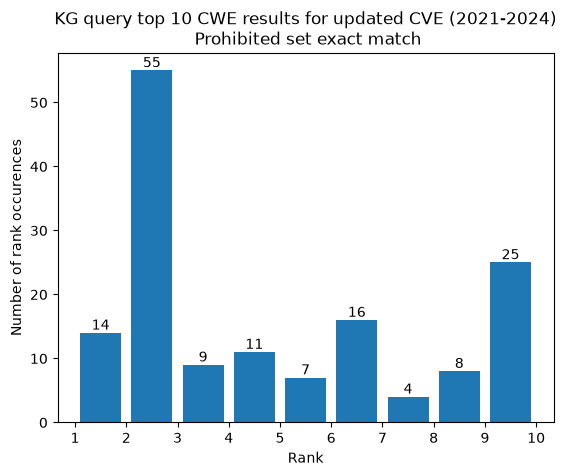

Mean Rank: 4.382550335570469
Mean Reciprocal Rank: 0.3728507510386705
Hits@1: 0.09395973154362416
Hits@3: 0.5234899328859061
Hits@5: 0.6442953020134228


In [39]:
bins = np.arange(1, 11)
counts, edges, bars = plt.hist(ranks, rwidth=0.8, bins=bins)
plt.bar_label(bars)
plt.xlabel("Rank")
plt.ylabel("Number of rank occurences")
plt.title("KG query top 10 CWE results for updated CVE (2021-2024)\n Prohibited set exact match")
plt.xticks(bins)
plt.show()
get_metrics(ranks)

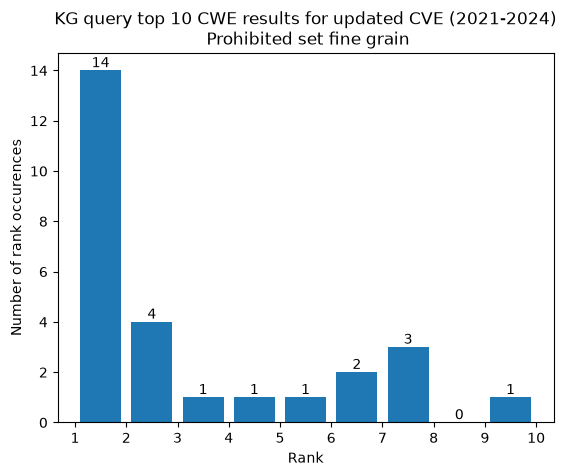

Mean Rank: 2.8518518518518516
Mean Reciprocal Rank: 0.6535273368606702
Hits@1: 0.5185185185185185
Hits@3: 0.7037037037037037
Hits@5: 0.7777777777777778


In [40]:
counts, edges, bars = plt.hist(ranks_fine,rwidth=0.8, bins=bins)
plt.bar_label(bars)
plt.xlabel("Rank")
plt.ylabel("Number of rank occurences")
plt.title("KG query top 10 CWE results for updated CVE (2021-2024)\n Prohibited set fine grain")
plt.xticks(bins)
plt.show()
get_metrics(ranks_fine) 

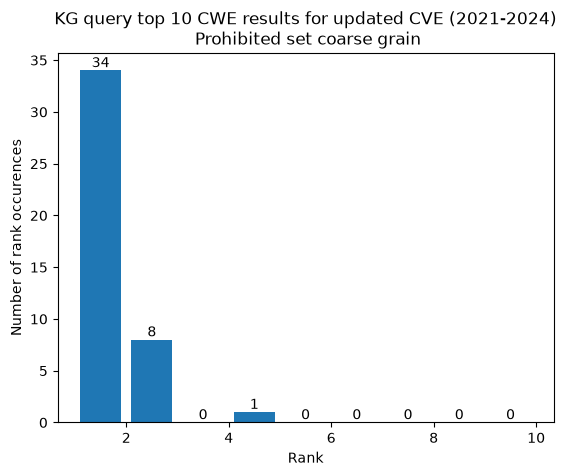

Mean Rank: 1.255813953488372
Mean Reciprocal Rank: 0.8895348837209303
Hits@1: 0.7906976744186046
Hits@3: 0.9767441860465116
Hits@5: 1.0


In [41]:
counts, edges, bars = plt.hist(ranks_coarse,rwidth=0.8, bins = np.arange(1, 11))
plt.bar_label(bars)
plt.xlabel("Rank")
plt.ylabel("Number of rank occurences")
plt.title("KG query top 10 CWE results for updated CVE (2021-2024)\n Prohibited set coarse grain")
plt.show()
get_metrics(ranks_coarse)  

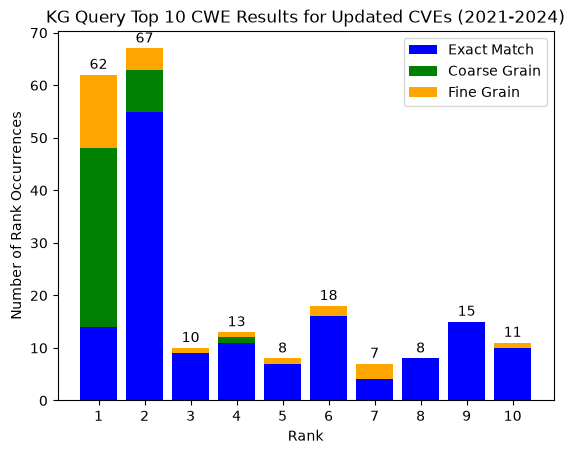

Mean Rank: 3.5799086757990866
Mean Reciprocal Rank: 0.5089041095890411
Hits@1: 0.2831050228310502
Hits@3: 0.634703196347032
Hits@5: 0.730593607305936


In [42]:
def plot_breakdown(ranks, ranks2, ranks3, topn):
    bins = np.arange(1, topn+1)
    hist1 = [ranks.count(b) for b in bins]
    hist2 = [ranks3.count(b) for b in bins]
    hist4 = [ranks2.count(b) for b in bins]
    
    total_heights = np.array(hist1) + np.array(hist2) + np.array(hist4)
    
    bar_width = 0.8
    plt.figure()
    bar1 = plt.bar(bins, hist1, width=bar_width, label='Exact Match', color='blue')
    bar2 = plt.bar(bins, hist2, width=bar_width, bottom=hist1, label='Coarse Grain', color='green')
    bar3 = plt.bar(bins, hist4, width=bar_width, bottom=np.array(hist1)+np.array(hist2), label='Fine Grain', color='orange')
    # Add total count on top of each bar
    for i, total in enumerate(total_heights):
        plt.text(bins[i], total + 0.5, str(total), ha='center', va="bottom")

    # Labels and legend
    plt.xlabel("Rank")
    plt.ylabel("Number of Rank Occurrences")
    plt.title("KG Query Top 10 CWE Results for Updated CVEs (2021-2024)")
    plt.xticks(bins)
    plt.legend()
    plt.show()


plot_breakdown(ranks, ranks_fine, ranks_coarse, 10)
get_metrics(ranks+ranks_fine+ranks_coarse)

### Discouraged Set

In [43]:
def get_1003_sublist(items):
    res = []
    for item in items:
        if item in cwe_1003 and item not in res:
            res.append(item)
    return res

In [44]:
results = {}
rel_id = relation2id['MatchingCWE']
total = 0
start = time.time()
for i, pair in tqdm(df_d.iterrows(), total=len(df_d)):
    cwe_q = pair['CWE']
    cve_q = pair['CVE']
    cwe_to_query = get_1003_sublist(get_cwe_children(cwe_q))
    if len(cwe_to_query) < 10:
        cwe_to_query = get_1003_sublist(get_sib_fam(cwe_q))
    candidate_tail_ids = [entity2id[cwe] for cwe in cwe_to_query if cwe != cwe_q]
    candidate_tail_ids = list(set(candidate_tail_ids))
    for cve in strtoList(cve_q):
        head_id = entity2id[cve]
        try:
            res = query_topn(model, head_id, rel_id, candidate_tail_ids)
            results[cve] = [res, cwe_q]
        except:
            pass
        total += 1
end = time.time()
elap = end - start
print(elap)
print(total)
print(elap/total)

  0%|          | 0/21 [00:00<?, ?it/s]

0.5319533348083496
1467
0.0003626130434958075


In [45]:
data = []

for cve, (predictions, old_cwe) in results.items():
    rank_labels = [id2entity[pred] for pred in predictions[0]]
    scores = predictions[1]

    data.append({
        'CVE': cve,
        'Rank': rank_labels,
        'Score': scores,
        'Old CWE': old_cwe
    })

df_res = pd.DataFrame(data)
df_res.to_csv('cwe_disc_query.csv', index=False)

In [46]:
results_df_disc = pd.read_csv('cwe_disc_query.csv', names=["CVE", "Result", "Score", 'Old CWE'], skiprows=1)

In [47]:
cwe_cve_d = []

for i, pair in df_d.iterrows():
    cwe_q = pair['CWE']
    cve_q = pair['CVE']

    for cve in strtoList(cve_q):
        new_cve = new_cve_df.loc[new_cve_df["subject:START_ID"] == cve]
        new_cwe = new_cve['object:END_ID'].values
        
        old_cve = df_cve2cwe[df_cve2cwe["CVE"]==cve]
        old_cwe = old_cve['CWE'].values
        
        #print(new_cwe, old_cwe)
        for item in new_cwe:
            if item not in old_cwe: # added this to avoid evaluating for already existing CWE mappings prior to validation
                cwe_cve_d.append((cwe_q, cve, item))
        
df_compare_d = pd.DataFrame(cwe_cve_d, columns=['OldCWE', 'CVE', 'CWE-NVD']) #,'CWE-KG'])
df_compare_d['CWE-KG'] = None

In [48]:
for item in cwe_cve_d:
    cve = item[1]
    row_d = df_compare_d.loc[df_compare_d['CVE']==cve]
    
    row = results_df_disc.loc[results_df_disc['CVE']==cve]
    if not row.empty:
        cwe_ranked = row["Result"].apply(ast.literal_eval).values[0]
        df_compare_d.loc[df_compare_d['CVE']==cve,'CWE-KG'] = str(cwe_ranked)

In [49]:
not_found = 0

exact_match = []
fine_grain = []
coarse_grain = []
other_cve = []

for index, row in df_compare_d.iterrows():
    cve = row["CVE"]
    
    oldCWE = row["OldCWE"]
    newCWE = row["CWE-NVD"]
    kg_str = row["CWE-KG"].replace("'", "")[1:-1]

    kg_list = kg_str.split(', ')    
    match = False
    
    if newCWE in kg_list:
        match = True
        rank = kg_list.index(newCWE) + 1
        exact_match.append((cve, newCWE, rank))
    
    else:
        fam = get_direct_family(newCWE)
        fam_all = get_cwe_family(newCWE)
        for result in kg_list:

            if result in fam:
                match = True
                rank = kg_list.index(result) + 1
                fine_grain.append((cve, result, rank))
                break

        if not match:
            for result in kg_list:
                if result in fam_all:
                    match = True
                    rank = kg_list.index(result) + 1
                    coarse_grain.append((cve, result, rank))
                    break
    if not match:
        not_found +=1
        other_cve.append((cve, newCWE))

In [50]:
print("Number of exact matches:", len(exact_match))
print("Number of fine-grain matches:", len(fine_grain))
print("Number of coarse-grain matches:", len(coarse_grain))
print("Number of mappings not predicted:", not_found)

Number of exact matches: 791
Number of fine-grain matches: 92
Number of coarse-grain matches: 4
Number of mappings not predicted: 593


In [51]:
df = pd.DataFrame(exact_match, columns=['CVE', 'CWE', 'Rank'])
df_fine = pd.DataFrame(fine_grain, columns=['CVE', 'CWE', 'Rank'])
df_coarse = pd.DataFrame(coarse_grain, columns=['CVE', 'CWE', 'Rank'])
# df_discPred = pd.DataFrame(disc_cve, columns = ['CVE','CWE','Rank'])
overall_df_d = pd.concat([df, df_fine, df_coarse])

In [52]:
overall_df_d.to_csv('disc_query_res.csv', index=False)

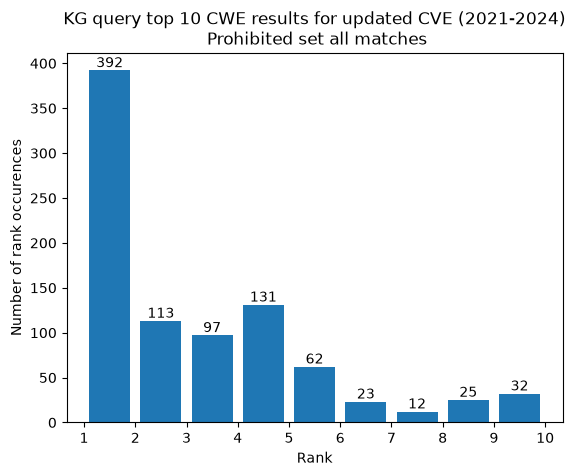

Mean Rank: 2.7801578354002254
Mean Reciprocal Rank: 0.6066145022458438
Hits@1: 0.4419391206313416
Hits@3: 0.6786922209695603
Hits@5: 0.8962795941375423


In [53]:
bins = np.arange(1, 11)
counts, edges, bars = plt.hist(overall_df_d['Rank'].values.tolist(), rwidth=0.8, bins=bins)
plt.bar_label(bars)
plt.xlabel("Rank")
plt.ylabel("Number of rank occurences")
plt.title("KG query top 10 CWE results for updated CVE (2021-2024)\n Prohibited set all matches")
plt.xticks(bins)
plt.show()
get_metrics(overall_df_d['Rank'].values.tolist())

In [54]:
ranks = df['Rank'].values.tolist()
ranks_fine = df_fine['Rank'].values.tolist()
ranks_coarse = df_coarse['Rank'].values.tolist()

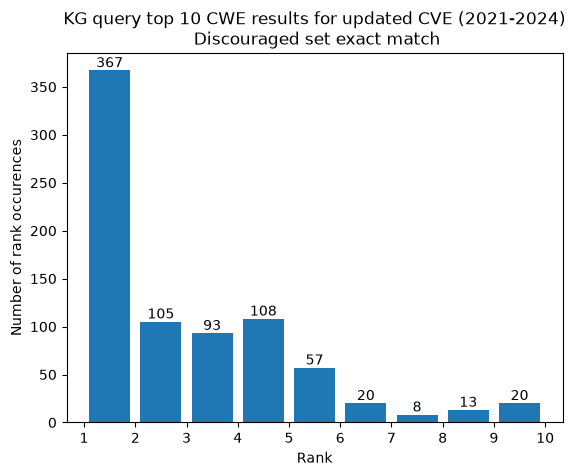

Mean Rank: 2.5790139064475346
Mean Reciprocal Rank: 0.6285026990147092
Hits@1: 0.4639696586599241
Hits@3: 0.7142857142857143
Hits@5: 0.922882427307206


In [55]:
counts, edges, bars = plt.hist(ranks, rwidth=0.8, bins=np.arange(1,11))
plt.bar_label(bars)
plt.xlabel("Rank")
plt.ylabel("Number of rank occurences")
plt.title("KG query top 10 CWE results for updated CVE (2021-2024)\n Discouraged set exact match")
plt.xticks(np.arange(1, 11))
plt.show()
get_metrics(ranks) 

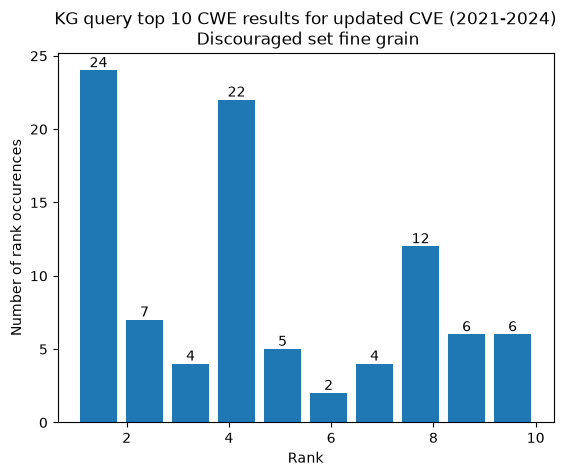

Mean Rank: 4.489130434782608
Mean Reciprocal Rank: 0.42396480331262937
Hits@1: 0.2608695652173913
Hits@3: 0.3804347826086957
Hits@5: 0.6739130434782609


In [56]:
counts, edges, bars = plt.hist(ranks_fine, rwidth=0.8)
plt.bar_label(bars)
plt.xlabel("Rank")
plt.ylabel("Number of rank occurences")
plt.title("KG query top 10 CWE results for updated CVE (2021-2024)\n Discouraged set fine grain")
plt.show()
get_metrics(ranks_fine)  

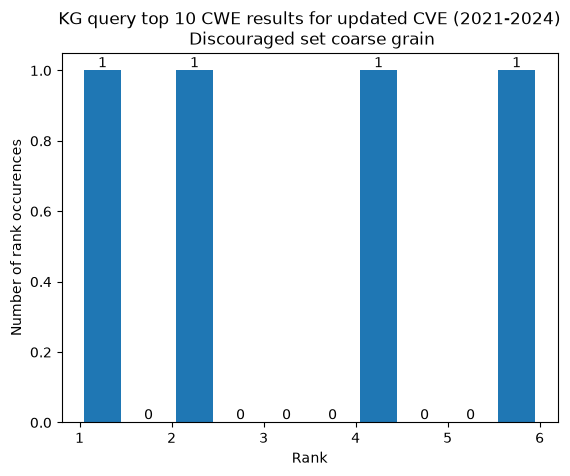

Mean Rank: 3.25
Mean Reciprocal Rank: 0.4791666666666667
Hits@1: 0.25
Hits@3: 0.5
Hits@5: 0.75


In [57]:
counts, edges, bars = plt.hist(ranks_coarse, rwidth=0.8)
plt.bar_label(bars)
plt.xlabel("Rank")
plt.ylabel("Number of rank occurences")
plt.title("KG query top 10 CWE results for updated CVE (2021-2024)\n Discouraged set coarse grain")
plt.show()
get_metrics(ranks_coarse)  

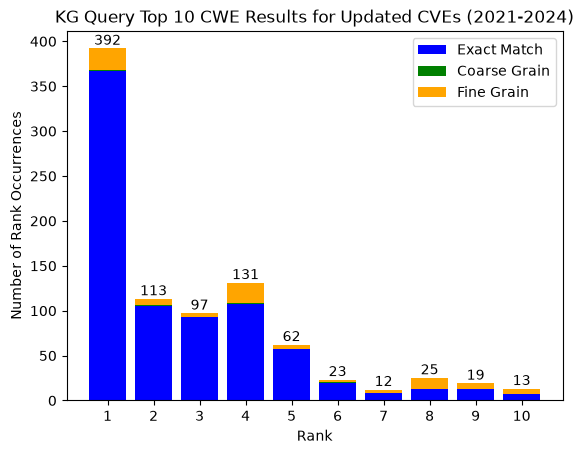

Mean Rank: 2.7801578354002254
Mean Reciprocal Rank: 0.6066145022458438
Hits@1: 0.4419391206313416
Hits@3: 0.6786922209695603
Hits@5: 0.8962795941375423


In [58]:
plot_breakdown(ranks, ranks_fine, ranks_coarse, 10)
get_metrics(ranks+ranks_fine+ranks_coarse)